### Arguments:
    k               : number of arms (default 10)
    walks           : standard deviation for the random walk
    num_steps       : number of steps per run
    num_exp         : number of independent experiments
    epsilon         : epsilon-greedy parameter
    alpha           : constant step-size parameter
    sample_average  : if True, use sample-average update; if False, use constant step-size update with alpha
    
Returns:
    avg_rewards     : array of shape (num_steps,) with average reward over time
    opt_arms        : array of shape (num_steps,) with % times optimal arm chosen

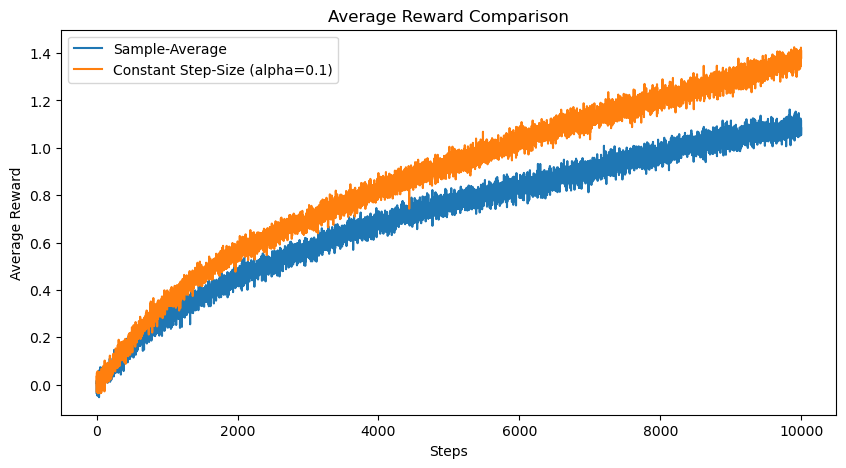

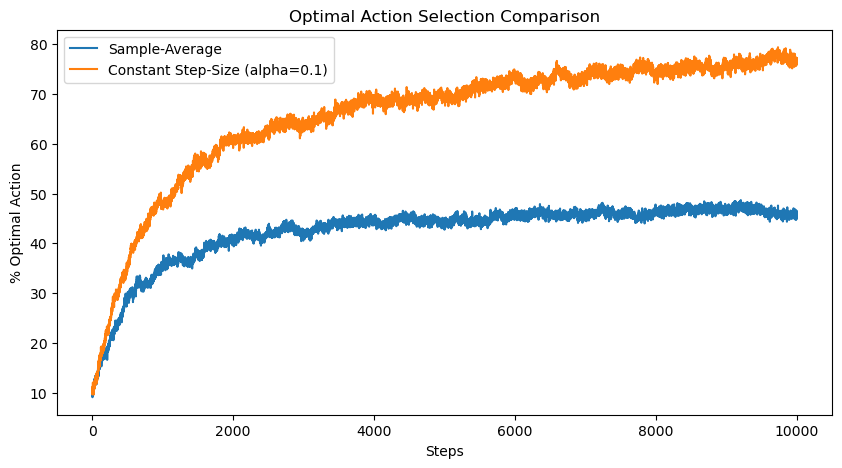

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

np.random.seed(1)

class ten_armed_bandit:
    def __init__(self, k=10, walks=0.01):
        self.arms = k
        self.walks = walks
        self.q_t = np.zeros(k)
        
    def reward(self, arm):
        return np.random.normal(self.q_t[arm], 1)

    def update_q_t(self):
        self.q_t += np.random.normal(0, self.walks, self.arms)

    def find_best_arm(self):
        return np.argmax(self.q_t)

def run_bandit_experiment(k=10, walks=0.01, num_steps=10000, num_exp=2000, epsilon=0.1, alpha=0.1, sample_average=True):

    avg_rewards = np.zeros(num_steps)
    opt_arms    = np.zeros(num_steps)

    for _ in range(num_exp):
        
        bandit = ten_armed_bandit(k=k, walks=walks)
        
        # Estimated action values and counts
        est_Q = np.zeros(k)
        arm_counts = np.zeros(k)

        for step in range(num_steps):
            # Epsilon-greedy action selection
            if np.random.rand() < epsilon:
                arm = np.random.randint(k)   # explore
            else:
                arm = np.argmax(est_Q)       # exploit

            # Get the reward from the chosen arm
            reward = bandit.reward(arm)

            # Random-walk: update the true action-values
            bandit.update_q_t()

            # Check if we chose the current true best arm
            opt_arm = bandit.find_best_arm()

            # Update estimates
            if sample_average:
                arm_counts[arm] += 1
                est_Q[arm] += (reward - est_Q[arm]) / arm_counts[arm]
            else:
                # constant step-size update
                est_Q[arm] += alpha * (reward - est_Q[arm])

            # Accumulate statistics
            avg_rewards[step] += reward
            if arm == opt_arm:
                opt_arms[step] += 1

    # Average over the number of experiments
    avg_rewards /= num_exp
    opt_arms = (opt_arms / num_exp) * 100.0

    return avg_rewards, opt_arms


# ---------------------------------------------------
# Now run both methods and compare
# ---------------------------------------------------

num_arms   = 10
num_steps  = 10000
num_exp    = 2000
epsilon    = 0.1
alpha      = 0.1
random_walks = 0.01

# Sample-Average method (SA)
avg_rewards_SA, opt_arms_SA = run_bandit_experiment(
    k=num_arms,
    walks=random_walks,
    num_steps=num_steps,
    num_exp=num_exp,
    epsilon=epsilon,
    alpha=alpha,
    sample_average=True
)

# Constant Step-Size method (CS)
avg_rewards_CS, opt_arms_CS = run_bandit_experiment(
    k=num_arms,
    walks=random_walks,
    num_steps=num_steps,
    num_exp=num_exp,
    epsilon=epsilon,
    alpha=alpha,
    sample_average=False
)

# ---------------------------------------------------
# Plotting
# ---------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(avg_rewards_SA, label="Sample-Average")
plt.plot(avg_rewards_CS, label="Constant Step-Size (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("Average Reward")
plt.title("Average Reward Comparison")
plt.legend()
plt.show()

plt.figure(figsize=(10, 5))
plt.plot(opt_arms_SA, label="Sample-Average")
plt.plot(opt_arms_CS, label="Constant Step-Size (alpha=0.1)")
plt.xlabel("Steps")
plt.ylabel("% Optimal Action")
plt.title("Optimal Action Selection Comparison")
plt.legend()
plt.show()
